In [2]:
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms

from tempfile import TemporaryDirectory
import matplotlib.pyplot as plt
import numpy as np
import os

In [3]:
## Preprocessing ##
data_transforms = {
    # Training data - augmentation + normalization
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    # Validation data - normalization
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

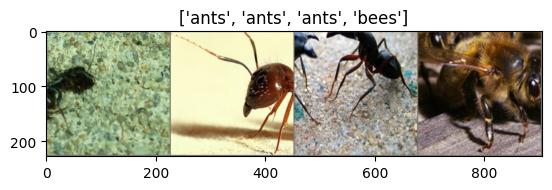

In [4]:
img_datasets = {x: datasets.ImageFolder(os.path.join('data', x), data_transforms[x])
               for x in ['train', 'val']}
dataloaders = {x: DataLoader(img_datasets[x], batch_size=4, shuffle=True) # num_workers=4
              for x in ['train', 'val']}
dataset_sizes = {x: len(img_datasets[x]) 
                for x in ['train', 'val']}
class_names = img_datasets['train'].classes

# Helper function to display images
def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause so plots update

inputs, classes = next(iter(dataloaders['train'])) # get batch
out = torchvision.utils.make_grid(inputs) # make grid from batch
imshow(out, title=[class_names[x] for x in classes]) # show grid

In [5]:
## Train/Eval Function ##
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):

    # Use temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 25)

            for phase in ['train', 'val']:
                if phase == 'train': model.train()
                else: model.eval()

                running_loss = 0.0
                running_corrects = 0

                for inputs, labels in dataloaders[phase]:
                    # inputs, labels = inputs.to(device), labels.to(device)

                    # If training, enable grad tracking
                    # Block still runs during validation, just w/o grad tracking
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        # torch.max() returns a tuple of (values, indices)
                        # We only need the index (corresponding to the predicted class)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        if phase == 'train':
                            optimizer.zero_grad()
                            loss.backward()
                            optimizer.step()

                    # Total loss per batch (multiply by batch size because loss is averaged)
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                
                # Step scheduler for learning rate decay
                if phase == 'train':
                    scheduler.step()

                # Avg loss and accuracy per epoch
                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]
                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
                
                # Save model if validation accuracy improves
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_params_path)

            print() # spacing
        print(f'Best val Acc: {best_acc:4f}')

        # Load best model
        model.load_state_dict(torch.load(best_params_path, weights_only=True))
    return model

In [6]:
# Helper function to visualize model predictions
def visualize_model(model, num_images=6):
    # Save current mode to restore
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            # inputs = inputs.to(device)
            # labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        plt.tight_layout()
        plt.show()
        model.train(mode=was_training)

In [ ]:
## Fine-tuning *** ##
model_ft = models.resnet18(weights='IMAGENET1K_V1')

# Replace final layer
num_ftrs = model_ft.fc.in_features 
model_ft.fc = nn.Linear(num_ftrs, 2) # only have 2 classes
# model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()
# Observe that all parameters are being optimized ***
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)
# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler, num_epochs=25)
torch.save(model_ft.state_dict(), 'resnet18_ft.pth')
print("Saved model_ft to resnet18_ft.pth")

14.3%

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\benjz/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


Epoch 0/24
-------------------------
train Loss: 0.5953 Acc: 0.7418
val Loss: 0.2477 Acc: 0.8954

Epoch 1/24
-------------------------
train Loss: 0.5546 Acc: 0.7787
val Loss: 0.2005 Acc: 0.9085

Epoch 2/24
-------------------------
train Loss: 0.3741 Acc: 0.8320
val Loss: 0.2648 Acc: 0.9216

Epoch 3/24
-------------------------
train Loss: 0.5382 Acc: 0.7828
val Loss: 0.9052 Acc: 0.7386

Epoch 4/24
-------------------------
train Loss: 0.6204 Acc: 0.7705
val Loss: 0.2839 Acc: 0.9020

Epoch 5/24
-------------------------
train Loss: 0.4555 Acc: 0.8197
val Loss: 0.4362 Acc: 0.8366

Epoch 6/24
-------------------------
train Loss: 0.5238 Acc: 0.8238
val Loss: 0.3647 Acc: 0.8693

Epoch 7/24
-------------------------
train Loss: 0.4160 Acc: 0.8115
val Loss: 0.1801 Acc: 0.9281

Epoch 8/24
-------------------------
train Loss: 0.3171 Acc: 0.8402
val Loss: 0.1896 Acc: 0.9281

Epoch 9/24
-------------------------
train Loss: 0.3318 Acc: 0.8730
val Loss: 0.2056 Acc: 0.9085

Epoch 10/24
--------

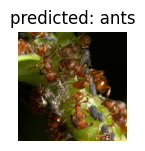

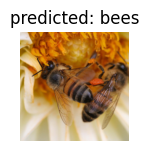

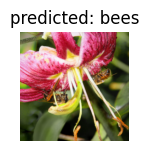

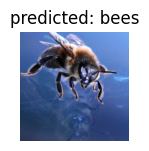

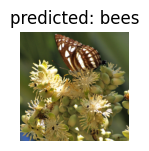

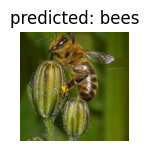

In [8]:
visualize_model(model_ft)

In [ ]:
## Fixed Feature Extraction *** ##
model_conv = models.resnet18(weights='IMAGENET1K_V1')
# Freeze all layers ***
for param in model_conv.parameters():
    param.requires_grad = False

# Replace final layer - requires grad=True by default
num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 2)
# model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()
# Observe that only final layer parameters are being optimized ***
optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)
# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

model_conv = train_model(model_conv, criterion, optimizer_conv, exp_lr_scheduler, num_epochs=25)
torch.save(model_conv.state_dict(), 'resnet18_conv.pth')
print("Saved model_conv to resnet18_conv.pth")

Epoch 0/24
-------------------------
train Loss: 0.5658 Acc: 0.6967
val Loss: 0.2433 Acc: 0.9150

Epoch 1/24
-------------------------
train Loss: 0.3424 Acc: 0.8525
val Loss: 0.1627 Acc: 0.9542

Epoch 2/24
-------------------------
train Loss: 0.4840 Acc: 0.7828
val Loss: 0.1748 Acc: 0.9608

Epoch 3/24
-------------------------
train Loss: 0.4109 Acc: 0.8033
val Loss: 0.2522 Acc: 0.8954

Epoch 4/24
-------------------------
train Loss: 0.6242 Acc: 0.7541
val Loss: 0.1857 Acc: 0.9216

Epoch 5/24
-------------------------
train Loss: 0.4402 Acc: 0.8156
val Loss: 0.2175 Acc: 0.9085

Epoch 6/24
-------------------------
train Loss: 0.2975 Acc: 0.8648
val Loss: 0.1537 Acc: 0.9739

Epoch 7/24
-------------------------
train Loss: 0.3664 Acc: 0.8566
val Loss: 0.1603 Acc: 0.9608

Epoch 8/24
-------------------------
train Loss: 0.3652 Acc: 0.8320
val Loss: 0.1688 Acc: 0.9542

Epoch 9/24
-------------------------
train Loss: 0.3193 Acc: 0.8689
val Loss: 0.1623 Acc: 0.9608

Epoch 10/24
--------

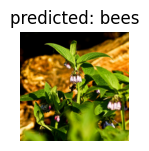

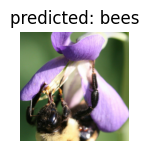

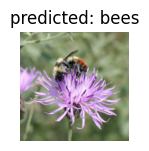

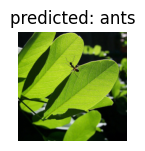

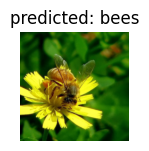

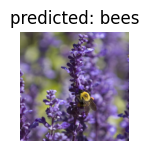

In [10]:
visualize_model(model_conv)